### 라이브러리 임포트

In [1]:
# --------------------------------------------------
# [1] 라이브러리 임포트 및 시각화 설정 
# --------------------------------------------------
import duckdb
import polars as pl
import pandas as pd
import os
import platform
import matplotlib.pyplot as plt
import seaborn as sns

# Polars, Pandas 출력 옵션 설정
pl.Config.set_tbl_rows(10)
pd.set_option('display.max_columns', 100)

# 🚨 반드시 Seaborn 임포트 이후에 폰트 설정 실행
if platform.system() == 'Darwin':  # Mac 환경
    plt.rc('font', family='Apple SD Gothic Neo')
elif platform.system() == 'Windows':  # Windows 환경
    plt.rc('font', family='Malgun Gothic')
else:  # Linux (Google Colab 등) 환경
    plt.rc('font', family='NanumGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

### 데이터 로드

In [2]:
# --------------------------------------------------
# [2] 파일 경로 설정 및 데이터 로드
# --------------------------------------------------
BASE_DIR = os.path.abspath('..')
PARQUET_PATH = os.path.join(BASE_DIR, 'data', 'processed', 'sdot_master_2020_2026_cleaned.parquet')

print(f"데이터 경로: {PARQUET_PATH}")
print(f"파일 존재 여부: {os.path.exists(PARQUET_PATH)}\n")

# DuckDB에 Parquet 파일을 뷰(v_sdot)로 즉시 등록
# -> 메모리를 적게 차지하며, 이후 SQL 쿼리에서 'v_sdot' 테이블명으로 바로 호출 가능
duckdb.sql(f"CREATE OR REPLACE VIEW v_sdot AS SELECT * FROM read_parquet('{PARQUET_PATH}')")

# --------------------------------------------------
# [3] 데이터 정상 로드 확인
# --------------------------------------------------
query_check = """
    SELECT * 
    FROM v_sdot
    LIMIT 5
"""
print("📌 [데이터 미리보기]")
display(duckdb.sql(query_check).pl())

데이터 경로: /Users/gomdori/Documents/Git/sdot-analysis/data/processed/sdot_master_2020_2026_cleaned.parquet
파일 존재 여부: True

📌 [데이터 미리보기]


measure_time,sensor_id,temp_max,temp_avg,temp_min,humi_max,humi_avg,humi_min,wind_spd_max,wind_spd_avg,wind_spd_min,wind_dir_max,wind_dir_avg,wind_dir_min,illu_max,illu_avg,illu_min,uv_max,uv_avg,uv_min,noise_max,noise_avg,noise_min,vibe_x_max_g,vibe_x_avg_g,vibe_x_min_g,vibe_y_max_g,vibe_y_avg_g,vibe_y_min_g,vibe_z_max_g,vibe_z_avg_g,vibe_z_min_g,vibe_x_max_mms,vibe_x_avg_mms,vibe_x_min_mms,vibe_y_max_mms,vibe_y_avg_mms,…,flag_vibe_z_avg_g,flag_vibe_z_min_g,flag_vibe_x_max_mms,flag_vibe_x_avg_mms,flag_vibe_x_min_mms,flag_vibe_y_max_mms,flag_vibe_y_avg_mms,flag_vibe_y_min_mms,flag_vibe_z_max_mms,flag_vibe_z_avg_mms,flag_vibe_z_min_mms,flag_wbgt_max,flag_wbgt_avg,flag_wbgt_min,flag_no2_max,flag_no2_avg,flag_no2_min,flag_co_max,flag_co_avg,flag_co_min,flag_so2_max,flag_so2_avg,flag_so2_min,flag_nh3_max,flag_nh3_avg,flag_nh3_min,flag_h2s_max,flag_h2s_avg,flag_h2s_min,flag_o3_max,flag_o3_avg,flag_o3_min,flag_pm10,flag_pm25,latitude,longitude,gu_name
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,str
"""2020-10-30 19:00""","""V02Q1940287""",null,15.9,null,null,39.0,null,0.0,0.0,null,0.0,0.0,null,null,0.0,null,null,0.0,null,null,44.0,null,0.13,0.06,null,0.12,0.01,null,1.09,1.02,null,null,null,null,null,null,…,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,37.531463,126.830075,"""양천구"""
"""2020-10-30 19:00""","""V02Q1940054""",null,16.1,null,null,36.0,null,0.0,0.0,null,0.0,0.0,null,null,0.0,null,null,0.0,null,null,45.0,null,0.08,0.02,null,0.15,0.08,null,1.28,1.06,null,null,null,null,null,null,…,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,37.490491,126.855378,"""구로구"""
"""2020-10-30 19:00""","""V02Q1940807""",null,18.6,null,null,26.0,null,0.0,0.0,null,0.0,0.0,null,null,0.0,null,null,0.0,null,null,49.0,null,0.14,0.07,null,0.16,0.1,null,1.12,1.06,null,null,null,null,null,null,…,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,37.573116,127.020059,"""종로구"""
"""2020-10-30 19:00""","""V02Q1940799""",null,16.2,null,null,34.0,null,0.0,0.0,null,0.0,0.0,null,null,0.0,null,null,0.0,null,null,46.0,null,0.07,0.02,null,0.12,0.02,null,1.11,1.06,null,null,null,null,null,null,…,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,37.637817,127.038271,"""도봉구"""
"""2020-10-30 20:00""","""V02Q1940328""",null,14.8,null,null,36.0,null,0.0,0.0,null,0.0,0.0,null,null,0.0,null,null,0.0,null,null,46.0,null,0.08,0.02,null,0.13,0.06,null,1.13,1.06,null,null,null,null,null,null,…,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,37.603348,127.029376,"""성북구"""


### 분석 대상 컬럼 정의

In [3]:
import duckdb

# 1. 전체 컬럼 
all_cols = duckdb.sql("SELECT * FROM v_sdot LIMIT 0").df().columns.tolist()

# 2. 전체 컬럼을 인덱스 번호와 함께 예쁘게 출력해서 눈으로 확인하기
print("📌 [ 전체 컬럼 인덱스 맵 ]")
for i, col in enumerate(all_cols):
    print(f"[{i:3d}] {col}")

# --------------------------------------------------
# 3. Target Columns 추출 (옵션 B: 자동 필터링 강력 추천!)
# --------------------------------------------------
metadata_cols = ['sensor_id', 'measure_time'] 

target_cols = [
    col for col in all_cols 
    if col not in metadata_cols       # 1. 기본 정보 컬럼 제외
    and not col.startswith('flag_')   # 2. 'flag_' 로 시작하는 QC 컬럼 제외
]

print(f"\n✅ 최종 선택된 분석 대상 측정 지표 수: {len(target_cols)}개")
print("👉", target_cols)

📌 [ 전체 컬럼 인덱스 맵 ]
[  0] measure_time
[  1] sensor_id
[  2] temp_max
[  3] temp_avg
[  4] temp_min
[  5] humi_max
[  6] humi_avg
[  7] humi_min
[  8] wind_spd_max
[  9] wind_spd_avg
[ 10] wind_spd_min
[ 11] wind_dir_max
[ 12] wind_dir_avg
[ 13] wind_dir_min
[ 14] illu_max
[ 15] illu_avg
[ 16] illu_min
[ 17] uv_max
[ 18] uv_avg
[ 19] uv_min
[ 20] noise_max
[ 21] noise_avg
[ 22] noise_min
[ 23] vibe_x_max_g
[ 24] vibe_x_avg_g
[ 25] vibe_x_min_g
[ 26] vibe_y_max_g
[ 27] vibe_y_avg_g
[ 28] vibe_y_min_g
[ 29] vibe_z_max_g
[ 30] vibe_z_avg_g
[ 31] vibe_z_min_g
[ 32] vibe_x_max_mms
[ 33] vibe_x_avg_mms
[ 34] vibe_x_min_mms
[ 35] vibe_y_max_mms
[ 36] vibe_y_avg_mms
[ 37] vibe_y_min_mms
[ 38] vibe_z_max_mms
[ 39] vibe_z_avg_mms
[ 40] vibe_z_min_mms
[ 41] wbgt_max
[ 42] wbgt_avg
[ 43] wbgt_min
[ 44] no2_max
[ 45] no2_avg
[ 46] no2_min
[ 47] co_max
[ 48] co_avg
[ 49] co_min
[ 50] so2_max
[ 51] so2_avg
[ 52] so2_min
[ 53] nh3_max
[ 54] nh3_avg
[ 55] nh3_min
[ 56] h2s_max
[ 57] h2s_avg
[ 58] h2s_min

# step1. 센서 유효 수명 정의

In [4]:
import duckdb
import pandas as pd
import numpy as np

# 1. 위치 정보까지 포함하여 메타데이터 제외
metadata_cols = ['sensor_id', 'measure_time', 'latitude', 'longitude', 'gu_name'] 
target_cols = [
    col for col in all_cols 
    if col not in metadata_cols 
    and not col.startswith('flag_')
]
print(f"✅ 최종 분석 대상 지표: {len(target_cols)}개")

# 2. 62개 지표에 대한 동적 SQL 생성
null_sqls = [f"SUM(CASE WHEN {col} IS NULL THEN 1 ELSE 0 END) AS null_{col}" for col in target_cols]
valid_sqls = [f"COUNT({col}) AS valid_{col}" for col in target_cols]

dynamic_sql_selects = ",\n        ".join(null_sqls + valid_sqls)

query_step1 = f"""
    SELECT 
        sensor_id,
        MIN(TRY_CAST(REPLACE(measure_time, '_', ' ') AS TIMESTAMP)) AS first_seen,
        MAX(TRY_CAST(REPLACE(measure_time, '_', ' ') AS TIMESTAMP)) AS last_seen,
        COUNT(*) AS actual_db_rows,
        {dynamic_sql_selects}
    FROM v_sdot
    GROUP BY sensor_id
"""

print("🚀 [ Step 1: 62개 전체 지표에 대한 거대 집계 쿼리 실행 중...]")
df_base = duckdb.sql(query_step1).df()

print("📌 [ Step 1 결과 (Wide Table 미리보기) ]")
display(df_base.head())

✅ 최종 분석 대상 지표: 62개
🚀 [ Step 1: 62개 전체 지표에 대한 거대 집계 쿼리 실행 중...]


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

📌 [ Step 1 결과 (Wide Table 미리보기) ]


,sensor_id,first_seen,last_seen,actual_db_rows,null_temp_max,null_temp_avg,null_temp_min,null_humi_max,null_humi_avg,null_humi_min,null_wind_spd_max,null_wind_spd_avg,null_wind_spd_min,null_wind_dir_max,null_wind_dir_avg,null_wind_dir_min,null_illu_max,null_illu_avg,null_illu_min,null_uv_max,null_uv_avg,null_uv_min,null_noise_max,null_noise_avg,null_noise_min,null_vibe_x_max_g,null_vibe_x_avg_g,null_vibe_x_min_g,null_vibe_y_max_g,null_vibe_y_avg_g,null_vibe_y_min_g,null_vibe_z_max_g,null_vibe_z_avg_g,null_vibe_z_min_g,null_vibe_x_max_mms,null_vibe_x_avg_mms,null_vibe_x_min_mms,null_vibe_y_max_mms,null_vibe_y_avg_mms,null_vibe_y_min_mms,null_vibe_z_max_mms,null_vibe_z_avg_mms,null_vibe_z_min_mms,null_wbgt_max,null_wbgt_avg,null_wbgt_min,null_no2_max,null_no2_avg,null_no2_min,null_co_max,...,valid_illu_max,valid_illu_avg,valid_illu_min,valid_uv_max,valid_uv_avg,valid_uv_min,valid_noise_max,valid_noise_avg,valid_noise_min,valid_vibe_x_max_g,valid_vibe_x_avg_g,valid_vibe_x_min_g,valid_vibe_y_max_g,valid_vibe_y_avg_g,valid_vibe_y_min_g,valid_vibe_z_max_g,valid_vibe_z_avg_g,valid_vibe_z_min_g,valid_vibe_x_max_mms,valid_vibe_x_avg_mms,valid_vibe_x_min_mms,valid_vibe_y_max_mms,valid_vibe_y_avg_mms,valid_vibe_y_min_mms,valid_vibe_z_max_mms,valid_vibe_z_avg_mms,valid_vibe_z_min_mms,valid_wbgt_max,valid_wbgt_avg,valid_wbgt_min,valid_no2_max,valid_no2_avg,valid_no2_min,valid_co_max,valid_co_avg,valid_co_min,valid_so2_max,valid_so2_avg,valid_so2_min,valid_nh3_max,valid_nh3_avg,valid_nh3_min,valid_h2s_max,valid_h2s_avg,valid_h2s_min,valid_o3_max,valid_o3_avg,valid_o3_min,valid_pm10,valid_pm25
0,V02Q1940490,2020-09-01,2026-07-26 23:07:00,49074,21486.0,432.0,21487.0,22118.0,505.0,21898.0,46347.0,46347.0,49074.0,46347.0,46347.0,49074.0,21487.0,0.0,21487.0,21504.0,81.0,21697.0,21486.0,477.0,21487.0,27654.0,27654.0,49074.0,27654.0,27653.0,49074.0,27592.0,27591.0,49074.0,29629.0,29626.0,29630.0,29629.0,29626.0,29630.0,29629.0,29626.0,29630.0,49074.0,48511.0,49074.0,49074.0,49074.0,49074.0,49074.0,...,27587,49074,27587,27570,48993,27377,27588,48597,27587,21420,21420,0,21420,21421,0,21482,21483,0,19445,19448,19444,19445,19448,19444,19445,19448,19444,0,563,0,0,0,0,0,0,0,0,0,0,0,0,0,0,28,28,13,13,13,177,177
1,V02Q1940133,2020-09-01,2026-07-26 23:07:00,44424,21593.0,387.0,21594.0,21874.0,221.0,21768.0,41883.0,41883.0,44424.0,41883.0,41883.0,44424.0,21593.0,15.0,21594.0,21611.0,34.0,21804.0,21593.0,291.0,21594.0,22897.0,22897.0,44424.0,22897.0,22896.0,44424.0,22835.0,22834.0,44424.0,21611.0,21608.0,21612.0,21611.0,21608.0,21612.0,21611.0,21608.0,21612.0,44424.0,43859.0,44424.0,44424.0,44424.0,44424.0,44424.0,...,22831,44409,22830,22813,44390,22620,22831,44133,22830,21527,21527,0,21527,21528,0,21589,21590,0,22813,22816,22812,22813,22816,22812,22813,22816,22812,0,565,0,0,0,0,0,0,0,0,0,0,0,0,0,0,30,30,17,17,17,177,177
2,V02Q1940454,2020-09-01,2026-07-26 23:07:00,48568,29552.0,8295.0,29552.0,29802.0,8075.0,29740.0,45841.0,45841.0,48568.0,45841.0,45841.0,48568.0,21701.0,0.0,21701.0,21718.0,429.0,21911.0,21700.0,477.0,21701.0,26934.0,26934.0,48568.0,26934.0,26933.0,48568.0,26872.0,26871.0,48568.0,21718.0,21715.0,21719.0,21718.0,21715.0,21719.0,21718.0,21715.0,21719.0,48568.0,48003.0,48568.0,48568.0,48568.0,48568.0,48568.0,...,26867,48568,26867,26850,48139,26657,26868,48091,26867,21634,21634,0,21634,21635,0,21696,21697,0,26850,26853,26849,26850,26853,26849,26850,26853,26849,0,565,0,0,0,0,0,0,0,0,0,0,0,0,0,0,30,30,16,16,16,177,177
3,V02Q1940083,2020-09-01,2026-07-26 23:07:00,48753,27975.0,6785.0,27975.0,28403.0,6787.0,28280.0,46026.0,46026.0,48753.0,46026.0,46026.0,48753.0,21548.0,15.0,21547.0,21565.0,25.0,21757.0,21737.0,667.0,21737.0,27269.0,27269.0,48753.0,27269.0,27268.0,48753.0,27207.0,27206.0,48753.0,21755.0,21755.0,21755.0,21755.0,21755.0,21755.0,21755.0,21755.0,21755.0,48753.0,48100.0,48753.0,48753.0,48753.0,48753.0,48753.0,...,27205,48738,27206,27188,48728,26996,27016,48086,27016,21484,21484,0,21484,21485,0,21546,21547,0,26998,26998,26998,26998,26998,

# step2. 기대 측정 횟수 계산

### 센서별 수집 주기 확인

In [5]:
import duckdb
import pandas as pd

# 센서별 실제 수집 주기(시간 간격) 정밀 검증 
query_sensor_intervals = """
    WITH time_diffs AS (
        -- 1. 센서별로 정렬한 뒤, 현재 시간과 바로 직전(LAG) 데이터의 시간을 나란히 붙임
        SELECT 
            sensor_id,
            TRY_CAST(REPLACE(measure_time, '_', ' ') AS TIMESTAMP) AS curr_time,
            LAG(TRY_CAST(REPLACE(measure_time, '_', ' ') AS TIMESTAMP)) 
                OVER (PARTITION BY sensor_id ORDER BY TRY_CAST(REPLACE(measure_time, '_', ' ') AS TIMESTAMP)) AS prev_time
        FROM v_sdot
    ),
    gaps AS (
        -- 2. 현재 시간과 직전 시간의 차이(분 단위)를 계산
        SELECT 
            sensor_id,
            DATE_DIFF('minute', prev_time, curr_time) AS gap_mins
        FROM time_diffs
        WHERE prev_time IS NOT NULL 
          AND DATE_DIFF('minute', prev_time, curr_time) > 0 -- 중복 적재 에러 방어
    )
    SELECT 
        sensor_id,
        -- 평균은 결측 공백 때문에 튀므로, '가장 자주 발생한 간격(최빈값)'을 해당 센서의 기본 세팅 주기로 간주
        MODE(gap_mins) AS 최빈_간격_분,
        MEDIAN(gap_mins) AS 중앙값_간격_분
    FROM gaps
    GROUP BY sensor_id
"""

print("🚀 [ 센서별 실제 수집 간격 정밀 분석 중... (약 10~30초 소요) ]")
df_intervals = duckdb.sql(query_sensor_intervals).df()

# --------------------------------------------------
# 결과 요약: 과연 60분이 아닌 센서가 존재할까?
# --------------------------------------------------
print("\n📌 [ 1,200개 센서들의 '기본 세팅 수집 간격' 분포 요약 ]")
interval_counts = df_intervals['최빈_간격_분'].value_counts().reset_index()
interval_counts.columns = ['실제 세팅 간격(분)', '해당 센서 개수(대)']
display(interval_counts)

🚀 [ 센서별 실제 수집 간격 정밀 분석 중... (약 10~30초 소요) ]


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


📌 [ 1,200개 센서들의 '기본 세팅 수집 간격' 분포 요약 ]


,실제 세팅 간격(분),해당 센서 개수(대)
0,60,1188
1,2820,1


### 사라진 11대 센서 확인

In [6]:
import duckdb
import pandas as pd


query_missing_11 = """
    WITH sensor_stats AS (
        SELECT 
            sensor_id,
            COUNT(*) AS total_records,
            -- 센서별 최초 및 최후 측정 시간 추출
            MIN(TRY_CAST(REPLACE(measure_time, '_', ' ') AS TIMESTAMP)) AS first_seen,
            MAX(TRY_CAST(REPLACE(measure_time, '_', ' ') AS TIMESTAMP)) AS last_seen
        FROM v_sdot
        GROUP BY sensor_id
    )
    SELECT 
        sensor_id,
        total_records AS 누적_전송_건수,
        first_seen AS 최초_시간,
        last_seen AS 최후_시간,
        -- 최초 시간과 최후 시간이 같다는 것은 '시간 간격(gap)'이 0이라는 뜻입니다.
        CASE 
            WHEN first_seen IS NULL THEN '🔴 타임스탬프 에러 (시간 파싱 불가)'
            WHEN first_seen = last_seen AND total_records = 1 THEN '🟡 평생 단 1건 전송 (간격 계산 불가)'
            WHEN first_seen = last_seen AND total_records > 1 THEN '🟠 타임스탬프 중복 (모든 데이터 시간이 동일)'
            ELSE '기타'
        END AS 이상_유형
    FROM sensor_stats
    -- 최초 시간과 최후 시간이 동일하거나 아예 NULL인 센서(즉, 11대)만 필터링
    WHERE first_seen = last_seen OR first_seen IS NULL
    ORDER BY 누적_전송_건수 DESC, sensor_id
"""

print("🔎 [ 사라진 11대 센서 정밀 검증 및 이상 유형 분류 ]")
df_missing_11 = duckdb.sql(query_missing_11).df()
display(df_missing_11)

🔎 [ 사라진 11대 센서 정밀 검증 및 이상 유형 분류 ]


,sensor_id,누적_전송_건수,최초_시간,최후_시간,이상_유형
0,V02Q1940982,65,NaT,NaT,🔴 타임스탬프 에러 (시간 파싱 불가)
1,V02Q1950001,18,NaT,NaT,🔴 타임스탬프 에러 (시간 파싱 불가)
2,V02Q1940963,4,NaT,NaT,🔴 타임스탬프 에러 (시간 파싱 불가)
3,OC3CL200001,1,2021-01-07 15:07:00,2021-01-07 15:07:00,🟡 평생 단 1건 전송 (간격 계산 불가)
4,OT2CL190005,1,2021-01-15 17:07:00,2021-01-15 17:07:00,🟡 평생 단 1건 전송 (간격 계산 불가)
5,OT2CL200002,1,NaT,NaT,🔴 타임스탬프 에러 (시간 파싱 불가)
6,OT3CL110000,1,2022-02-17 11:07:00,2022-02-17 11:07:00,🟡 평생 단 1건 전송 (간격 계산 불가)
7,V02Q1940921,1,NaT,NaT,🔴 타임스탬프 에러 (시간 파싱 불가)
8,V02Q1940922,1,NaT,NaT,🔴 타임스탬프 에러 (시간 파싱 불가)
9,V02Q1940933,1,NaT,NaT,🔴 타임스탬프 에러 (시간 파싱 불가)


In [10]:
import duckdb
import os

BASE_DIR = os.path.abspath('..')
PARQUET_PATH = os.path.join(
    BASE_DIR,
    'data',
    'processed',
    'sdot_master_2020_2026_cleaned.parquet'
)

duckdb.sql(f"""
    CREATE OR REPLACE VIEW v_sdot AS
    SELECT *
    FROM read_parquet('{PARQUET_PATH}')
""")

print("✅ v_sdot 원본 뷰 복구 완료")

display(
    duckdb.sql("""
        SELECT *
        FROM v_sdot
        LIMIT 5
    """).df()
)

✅ v_sdot 원본 뷰 복구 완료


,measure_time,sensor_id,temp_max,temp_avg,temp_min,humi_max,humi_avg,humi_min,wind_spd_max,wind_spd_avg,wind_spd_min,wind_dir_max,wind_dir_avg,wind_dir_min,illu_max,illu_avg,illu_min,uv_max,uv_avg,uv_min,noise_max,noise_avg,noise_min,vibe_x_max_g,vibe_x_avg_g,vibe_x_min_g,vibe_y_max_g,vibe_y_avg_g,vibe_y_min_g,vibe_z_max_g,vibe_z_avg_g,vibe_z_min_g,vibe_x_max_mms,vibe_x_avg_mms,vibe_x_min_mms,vibe_y_max_mms,vibe_y_avg_mms,vibe_y_min_mms,vibe_z_max_mms,vibe_z_avg_mms,vibe_z_min_mms,wbgt_max,wbgt_avg,wbgt_min,no2_max,no2_avg,no2_min,co_max,co_avg,co_min,...,flag_uv_max,flag_uv_avg,flag_uv_min,flag_noise_max,flag_noise_avg,flag_noise_min,flag_vibe_x_max_g,flag_vibe_x_avg_g,flag_vibe_x_min_g,flag_vibe_y_max_g,flag_vibe_y_avg_g,flag_vibe_y_min_g,flag_vibe_z_max_g,flag_vibe_z_avg_g,flag_vibe_z_min_g,flag_vibe_x_max_mms,flag_vibe_x_avg_mms,flag_vibe_x_min_mms,flag_vibe_y_max_mms,flag_vibe_y_avg_mms,flag_vibe_y_min_mms,flag_vibe_z_max_mms,flag_vibe_z_avg_mms,flag_vibe_z_min_mms,flag_wbgt_max,flag_wbgt_avg,flag_wbgt_min,flag_no2_max,flag_no2_avg,flag_no2_min,flag_co_max,flag_co_avg,flag_co_min,flag_so2_max,flag_so2_avg,flag_so2_min,flag_nh3_max,flag_nh3_avg,flag_nh3_min,flag_h2s_max,flag_h2s_avg,flag_h2s_min,flag_o3_max,flag_o3_avg,flag_o3_min,flag_pm10,flag_pm25,latitude,longitude,gu_name
0,2020-10-30 19:00,V02Q1940287,NaN,15.9,NaN,NaN,39.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,44.0,NaN,0.13,0.06,NaN,0.12,0.01,NaN,1.09,1.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,1,1,1,1,1,1,1,0,1,1,0,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,37.531463,126.830075,양천구
1,2020-10-30 19:00,V02Q1940054,NaN,16.1,NaN,NaN,36.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,45.0,NaN,0.08,0.02,NaN,0.15,0.08,NaN,1.28,1.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,1,1,1,1,1,1,1,0,1,1,0,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,37.490491,126.855378,구로구
2,2020-10-30 19:00,V02Q1940807,NaN,18.6,NaN,NaN,26.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,49.0,NaN,0.14,0.07,NaN,0.16,0.10,NaN,1.12,1.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,1,1,1,1,1,1,1,0,1,1,0,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,37.573116,127.020059,종로구
3,2020-10-30 19:00,V02Q1940799,NaN,16.2,NaN,NaN,34.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,46.0,NaN,0.07,0.02,NaN,0.12,0.02,NaN,1.11,1.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,1,1,1,1,1,1,1,0,1,1,0,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,37.637817,127.038271,도봉구
4,2020-10-30 20:00,V02Q1940328,NaN,14.8,NaN,NaN,36.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,46.0,NaN,0.08,0.02,NaN,0.13,0.06,NaN,1.13,1.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,1,1,1,1,1,1,1,0,1,1,0,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,37.603348,127.029376,성북구


### 시간 단위 표준화

In [11]:
query_fix_minute_issue = """
    CREATE OR REPLACE VIEW v_sdot_hourly AS 
    SELECT 
        * EXCLUDE (measure_time),
        CAST(
            CASE 
                WHEN measure_time LIKE '%.%' THEN 
                    STRFTIME(
                        STRPTIME(measure_time, '%Y.%m.%d %H:%M'),
                        '%Y-%m-%d %H:00:00'
                    )
                ELSE 
                    STRFTIME(
                        TRY_CAST(
                            REPLACE(measure_time, '_', ' ') 
                            AS TIMESTAMP
                        ),
                        '%Y-%m-%d %H:00:00'
                    )
            END 
        AS VARCHAR) AS measure_time
    FROM v_sdot
"""

duckdb.sql(query_fix_minute_issue)

print("✅ v_sdot → v_sdot_hourly 생성 완료")

✅ v_sdot → v_sdot_hourly 생성 완료


### 11대 센서 재확인

In [13]:
target_sensors = [
    'V02Q1940982',
    'V02Q1950001',
    'V02Q1940963',
    'OC3CL200001',
    'OT2CL190005',
    'OT2CL200002',
    'OT3CL110000',
    'V02Q1940921',
    'V02Q1940922',
    'V02Q1940933',
    'V02Q1940936'
]

query_recheck_11 = f"""
    WITH sensor_stats AS (
        SELECT 
            sensor_id,
            COUNT(*) AS total_records,
            MIN(TRY_CAST(measure_time AS TIMESTAMP)) AS first_seen,
            MAX(TRY_CAST(measure_time AS TIMESTAMP)) AS last_seen
        FROM v_sdot_hourly
        WHERE sensor_id IN ({','.join([repr(x) for x in target_sensors])})
        GROUP BY sensor_id
    )
    SELECT 
        sensor_id,
        total_records AS 누적_전송_건수,
        first_seen AS 최초_시간,
        last_seen AS 최후_시간,
        CASE 
            WHEN first_seen IS NULL 
                THEN '🔴 타임스탬프 에러 (시간 파싱 불가)'
            WHEN first_seen = last_seen AND total_records = 1 
                THEN '🟡 평생 단 1건 전송 (간격 계산 불가)'
            WHEN first_seen = last_seen AND total_records > 1 
                THEN '🟠 타임스탬프 중복 (모든 데이터 시간이 동일)'
            ELSE '기타'
        END AS 이상_유형
    FROM sensor_stats
    ORDER BY 누적_전송_건수 DESC, sensor_id
"""

df_recheck_11 = duckdb.sql(query_recheck_11).df()
display(df_recheck_11)

,sensor_id,누적_전송_건수,최초_시간,최후_시간,이상_유형
0,V02Q1940982,65,2020-04-01 01:00:00,2020-04-03 17:00:00,기타
1,V02Q1950001,18,2020-05-13 14:00:00,2020-05-14 08:00:00,기타
2,V02Q1940963,4,2020-04-02 15:00:00,2020-04-03 11:00:00,기타
3,OC3CL200001,1,2021-01-07 15:00:00,2021-01-07 15:00:00,🟡 평생 단 1건 전송 (간격 계산 불가)
4,OT2CL190005,1,2021-01-15 17:00:00,2021-01-15 17:00:00,🟡 평생 단 1건 전송 (간격 계산 불가)
5,OT2CL200002,1,2020-05-06 10:00:00,2020-05-06 10:00:00,🟡 평생 단 1건 전송 (간격 계산 불가)
6,OT3CL110000,1,2022-02-17 11:00:00,2022-02-17 11:00:00,🟡 평생 단 1건 전송 (간격 계산 불가)
7,V02Q1940921,1,2020-04-16 13:00:00,2020-04-16 13:00:00,🟡 평생 단 1건 전송 (간격 계산 불가)
8,V02Q1940922,1,2020-04-02 17:00:00,2020-04-02 17:00:00,🟡 평생 단 1건 전송 (간격 계산 불가)
9,V02Q1940933,1,2020-04-03 16:00:00,2020-04-03 16:00:00,🟡 평생 단 1건 전송 (간격 계산 불가)


In [14]:
query_check_3 = """
SELECT
    sensor_id,
    measure_time
FROM v_sdot
WHERE sensor_id IN (
    'V02Q1940982',
    'V02Q1950001',
    'V02Q1940963'
)
ORDER BY sensor_id, measure_time
"""

df_check_3 = duckdb.sql(query_check_3).df()
display(df_check_3)

,sensor_id,measure_time
0,V02Q1940963,2020.4.2 15:00
1,V02Q1940963,2020.4.3 10:00
2,V02Q1940963,2020.4.3 11:00
3,V02Q1940963,2020.4.3 9:00
4,V02Q1940982,2020.4.1 10:00
...,...,...
82,V02Q1950001,2020.5.14 4:45
83,V02Q1950001,2020.5.14 5:45
84,V02Q1950001,2020.5.14 6:46
85,V02Q1950001,2020.5.14 7:46


In [15]:
query_format_check = """
SELECT
    sensor_id,
    measure_time,
    CASE
        WHEN measure_time LIKE '%.%' THEN '점(.) 포맷'
        WHEN measure_time LIKE '%_%' THEN '언더스코어(_) 포맷'
        ELSE '기타'
    END AS 시간_포맷
FROM v_sdot
WHERE sensor_id IN (
    'V02Q1940982',
    'V02Q1950001',
    'V02Q1940963'
)
ORDER BY sensor_id, measure_time
"""

display(duckdb.sql(query_format_check).df())

,sensor_id,measure_time,시간_포맷
0,V02Q1940963,2020.4.2 15:00,점(.) 포맷
1,V02Q1940963,2020.4.3 10:00,점(.) 포맷
2,V02Q1940963,2020.4.3 11:00,점(.) 포맷
3,V02Q1940963,2020.4.3 9:00,점(.) 포맷
4,V02Q1940982,2020.4.1 10:00,점(.) 포맷
...,...,...,...
82,V02Q1950001,2020.5.14 4:45,점(.) 포맷
83,V02Q1950001,2020.5.14 5:45,점(.) 포맷
84,V02Q1950001,2020.5.14 6:46,점(.) 포맷
85,V02Q1950001,2020.5.14 7:46,점(.) 포맷


## 센서별 수집 주기 재확인

In [16]:
import duckdb
import pandas as pd

# 센서별 실제 수집 주기(시간 간격) 정밀 검증
query_sensor_intervals = """
    WITH time_diffs AS (
        SELECT 
            sensor_id,
            TRY_CAST(measure_time AS TIMESTAMP) AS curr_time,
            LAG(TRY_CAST(measure_time AS TIMESTAMP)) 
                OVER (
                    PARTITION BY sensor_id 
                    ORDER BY TRY_CAST(measure_time AS TIMESTAMP)
                ) AS prev_time
        FROM v_sdot_hourly
    ),
    gaps AS (
        SELECT 
            sensor_id,
            DATE_DIFF('minute', prev_time, curr_time) AS gap_mins
        FROM time_diffs
        WHERE prev_time IS NOT NULL 
          AND curr_time IS NOT NULL
          AND DATE_DIFF('minute', prev_time, curr_time) > 0
    )
    SELECT 
        sensor_id,
        MODE(gap_mins) AS 최빈_간격_분,
        MEDIAN(gap_mins) AS 중앙값_간격_분
    FROM gaps
    GROUP BY sensor_id
"""

print("🚀 [ 센서별 실제 수집 간격 정밀 분석 중... ]")

df_intervals = duckdb.sql(query_sensor_intervals).df()

print("\n📌 [ 센서들의 기본 세팅 수집 간격 분포 ]")

interval_counts = (
    df_intervals['최빈_간격_분']
    .value_counts()
    .reset_index()
)

interval_counts.columns = ['실제_세팅_간격_분', '해당_센서_개수']
display(interval_counts)

🚀 [ 센서별 실제 수집 간격 정밀 분석 중... ]


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


📌 [ 센서들의 기본 세팅 수집 간격 분포 ]


,실제_세팅_간격_분,해당_센서_개수
0,60,1192


## 기대 측정 횟수

In [18]:
# 1. 기대 측정 횟수(C)와 완전 누락(A) 계산 (1시간 1회 수집 기준)
df_base['expected_c'] = ((df_base['last_seen'] - df_base['first_seen']).dt.total_seconds() / 3600) + 1
df_base['expected_c'] = df_base['expected_c'].fillna(0).astype(int)
df_base['missing_a'] = np.maximum(df_base['expected_c'] - df_base['actual_db_rows'], 0)

# 2. 판다스 Melt로 데이터를 길게 풀기 (Wide -> Long)
df_nulls = df_base.melt(id_vars=['sensor_id', 'expected_c', 'missing_a'], 
                        value_vars=[f"null_{c}" for c in target_cols],
                        var_name='indicator', value_name='explicit_null_b')
df_nulls['indicator'] = df_nulls['indicator'].str.replace('null_', '')

df_valid = df_base.melt(id_vars=['sensor_id'], 
                        value_vars=[f"valid_{c}" for c in target_cols],
                        var_name='indicator', value_name='valid_count')
df_valid['indicator'] = df_valid['indicator'].str.replace('valid_', '')

df_long = pd.merge(df_nulls, df_valid, on=['sensor_id', 'indicator'])

# 3. 진짜 결측률 산출 함수
def calculate_true_missing(row):
    if row['expected_c'] <= 1:
        return np.nan # 수명이 1시간도 안 되는 에러 센서
    if row['valid_count'] == 0:
        return -1.0 # 💡 해당 지표를 평생 한 번도 측정한 적 없음 (미지원 기기)
    
    true_rate = ((row['missing_a'] + row['explicit_null_b']) / row['expected_c']) * 100
    return min(round(true_rate, 2), 100.0)

print("🚀 [ Step 2: '미지원 센서' 필터링 및 '진짜 결측률' 계산 중... ]")
df_long['true_missing_rate'] = df_long.apply(calculate_true_missing, axis=1)

print("📌 [ Step 2 결과 (Long Table 미리보기) ]")
display(df_long.head(10))

🚀 [ Step 2: '미지원 센서' 필터링 및 '진짜 결측률' 계산 중... ]
📌 [ Step 2 결과 (Long Table 미리보기) ]


,sensor_id,expected_c,missing_a,indicator,explicit_null_b,valid_count,true_missing_rate
0,V02Q1940490,51720,2646,temp_max,21486.0,27588,46.66
1,V02Q1940133,51720,7296,temp_max,21593.0,22831,55.86
2,V02Q1940454,51720,3152,temp_max,29552.0,19016,63.23
3,V02Q1940083,51720,2967,temp_max,27975.0,20778,59.83
4,V02Q1940353,51720,5918,temp_max,21817.0,23985,53.63
5,V02Q1940330,51720,4826,temp_max,21622.0,25272,51.14
6,V02Q1940409,51636,1530,temp_max,29559.0,20547,60.21
7,V02Q1940222,51720,4680,temp_max,21750.0,25290,51.10
8,V02Q1940097,51720,2036,temp_max,21708.0,27976,45.91
9,V02Q1940785,51720,2790,temp_max,21609.0,27321,47.18


# step3. 센서별 결측률 계산

In [19]:
# 1. 보기 좋게 다시 표 형태로 만들기 (행: 센서, 열: 62개 측정항목)
df_final_pivot = df_long.pivot(index='sensor_id', columns='indicator', values='true_missing_rate')
df_display = df_final_pivot.replace(-1.0, '❌ 미지원')

print("🚨 [ 1,200개 센서 x 62개 전체 지표 결측률 최종 매트릭스 ]")
display(df_display.head(20))

# 2. (보너스) 전체 센서 기준, 어떤 측정 항목이 제일 결측이 심한지(미지원 제외) 평균 내어보기
print("\n📊 [ 지표별 평균 결측률 Top 10 (어떤 센서가 제일 고장이 잦을까?) ]")
# 미지원(-1.0)과 에러(NaN)를 제외한 진짜 결측률 평균 계산
mean_missing_rates = df_final_pivot.replace(-1.0, np.nan).mean().sort_values(ascending=False)
display(pd.DataFrame(mean_missing_rates, columns=['평균 결측률(%)']).head(10))

🚨 [ 1,200개 센서 x 62개 전체 지표 결측률 최종 매트릭스 ]


indicator,co_avg,co_max,co_min,h2s_avg,h2s_max,h2s_min,humi_avg,humi_max,humi_min,illu_avg,illu_max,illu_min,nh3_avg,nh3_max,nh3_min,no2_avg,no2_max,no2_min,noise_avg,noise_max,noise_min,o3_avg,o3_max,o3_min,pm10,pm25,so2_avg,so2_max,so2_min,temp_avg,temp_max,temp_min,uv_avg,uv_max,uv_min,vibe_x_avg_g,vibe_x_avg_mms,vibe_x_max_g,vibe_x_max_mms,vibe_x_min_g,vibe_x_min_mms,vibe_y_avg_g,vibe_y_avg_mms,vibe_y_max_g,vibe_y_max_mms,vibe_y_min_g,vibe_y_min_mms,vibe_z_avg_g,vibe_z_avg_mms,vibe_z_max_g,vibe_z_max_mms,vibe_z_min_g,vibe_z_min_mms,wbgt_avg,wbgt_max,wbgt_min,wind_dir_avg,wind_dir_max,wind_dir_min,wind_spd_avg,wind_spd_max,wind_spd_min
sensor_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
OC3CL200001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OC3CL200008,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,48.18,73.56,73.5,98.9,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,98.9,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,48.1,73.44,73.44,98.9,❌ 미지원,❌ 미지원,98.9,❌ 미지원,98.9,❌ 미지원,❌ 미지원,❌ 미지원,98.9,❌ 미지원,98.9,❌ 미지원,❌ 미지원,❌ 미지원,98.9,❌ 미지원,98.9,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원
OC3CL200009,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,75.12,87.49,87.49,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,75.12,87.49,87.49,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원
OC3CL200010,❌ 미지원,❌ 미지원,❌ 미지원,47.15,45.9,47.16,38.03,60.38,58.53,100.0,❌ 미지원,100.0,45.89,45.9,45.9,❌ 미지원,❌ 미지원,❌ 미지원,24.45,45.82,45.83,99.95,99.95,99.95,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,44.35,65.09,65.09,26.32,46.54,46.59,❌ 미지원,100.0,❌ 미지원,100.0,❌ 미지원,100.0,❌ 미지원,100.0,❌ 미지원,100.0,❌ 미지원,100.0,❌ 미지원,100.0,❌ 미지원,100.0,❌ 미지원,100.0,75.49,96.14,96.14,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원
OC3CL200011,❌ 미지원,❌ 미지원,❌ 미지원,46.01,44.97,46.3,66.97,86.45,85.16,❌ 미지원,❌ 미지원,❌ 미지원,44.68,44.97,44.97,❌ 미지원,❌ 미지원,❌ 미지원,13.01,44.9,44.9,99.96,99.96,99.96,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,45.28,64.11,64.11,13.11,45.0,45.39,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,75.59,94.43,94.43,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원
OC3CL200012,❌ 미지원,❌ 미지원,❌ 미지원,49.02,48.0,49.32,27.04,59.61,58.3,❌ 미지원,❌ 미지원,❌ 미지원,47.89,48.19,48.19,❌ 미지원,❌ 미지원,❌ 미지원,16.07,47.95,47.95,99.97,99.97,99.97,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,16.64,47.93,47.93,16.53,48.4,48.8,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,63.07,94.26,94.26,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원
OC3CL200013,❌ 미지원,❌ 미지원,❌ 미지원,47.49,46.48,47.79,22.25,54.73,53.41,❌ 미지원,❌ 미지원,❌ 미지원,46.2,46.5,46.5,❌ 미지원,❌ 미지원,❌ 미지원,14.84,46.45,46.45,99.96,99.96,99.96,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,17.09,48.27,48.27,19.25,50.86,51.26,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,64.43,95.35,95.35,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원
OC3CL200014,❌ 미지원,❌ 미지원,❌ 미지원,41.83,40.87,42.13,45.72,77.57,77.45,❌ 미지원,❌ 미지원,❌ 미지원,40.58,40.88,40.88,❌ 미지원,❌ 미지원,❌ 미지원,8.97,40.74,40.75,99.96,99.96,99.96,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,46.08,77.28,77.28,9.01,40.78,41.18,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,63.94,95.06,95.06,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원
OC3CL200015,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,80.57,90.48,89.97,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,90.35,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,78.73,87.83,87.83,90.35,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,90.99,❌ 미지원,❌ 미지원,❌ 미지원,❌ 미지원,


📊 [ 지표별 평균 결측률 Top 10 (어떤 센서가 제일 고장이 잦을까?) ]


,평균 결측률(%)
indicator,
pm25,99.657515
pm10,99.657491
o3_min,97.709257
o3_max,97.709219
o3_avg,97.700939
wbgt_avg,96.888709
h2s_min,96.865759
h2s_avg,96.852444
wbgt_min,95.188750


In [17]:
# 1,200개 센서 x 62개 전체 지표 결측률 최종 매트릭스 csv 저장
output_csv_path = os.path.join(BASE_DIR, 'data', 'processed', 'sensor_missing_rates_matrix.csv')
df_final_pivot.to_csv(output_csv_path, index=True)
print(f"\n✅ 최종 결측률 매트릭스 CSV 저장 완료: {output_csv_path}") 


✅ 최종 결측률 매트릭스 CSV 저장 완료: /Users/gomdori/Documents/Git/sdot-analysis/data/processed/sensor_missing_rates_matrix.csv


# 센서 클러스터링 분포 시각화

/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_21837/291488926.py:66: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) AppleGothic.
  plt.tight_layout()
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_21837/291488926.py:66: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) AppleGothic.
  plt.tight_layout()
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_21837/291488926.py:66: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) AppleGothic.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/si

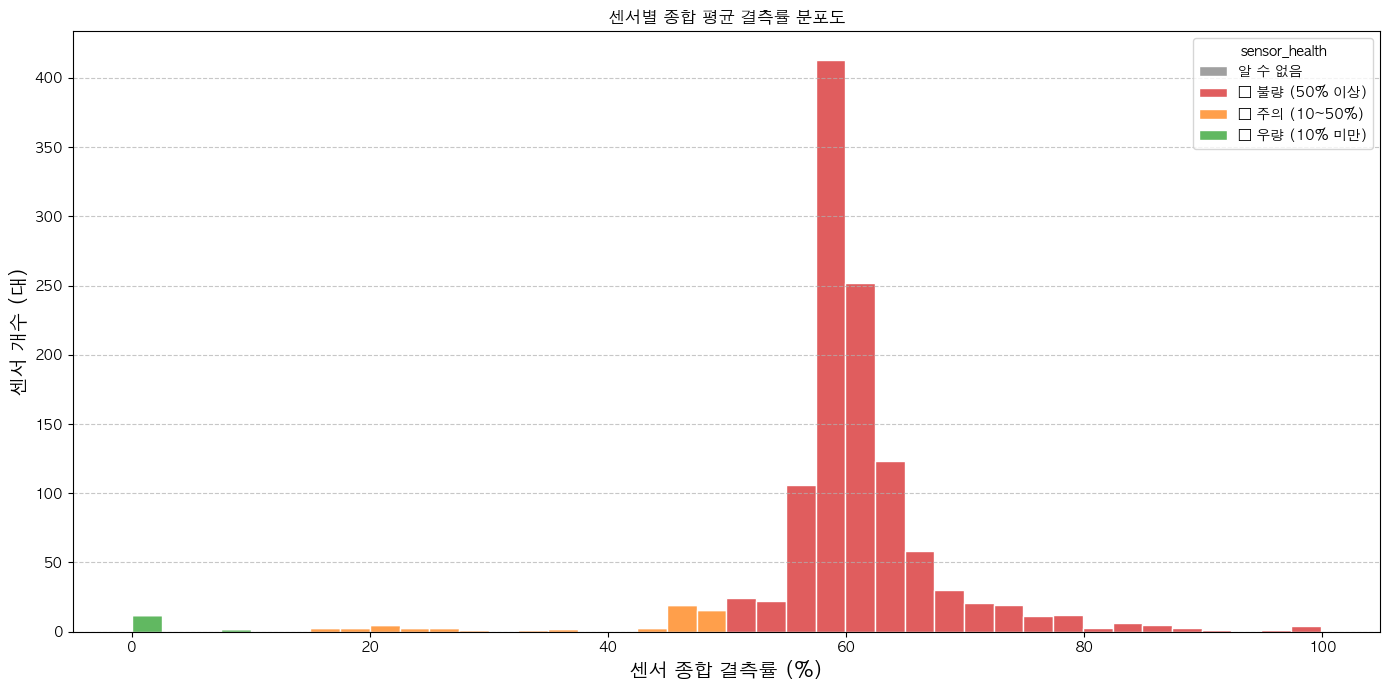

/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_21837/291488926.py:96: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) AppleGothic.
  plt.tight_layout()
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_21837/291488926.py:96: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) AppleGothic.
  plt.tight_layout()
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_21837/291488926.py:96: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) AppleGothic.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/si

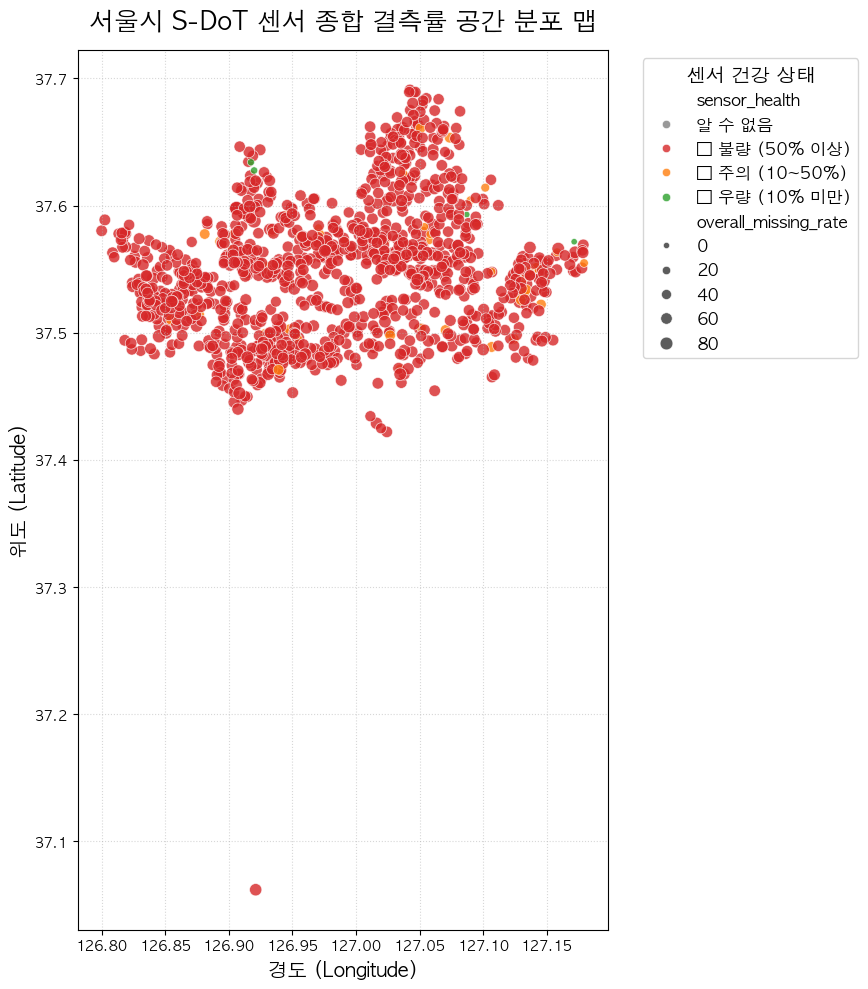

In [ ]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rc('font', family='AppleGothic') # Mac
plt.rcParams['axes.unicode_minus'] = False

# --------------------------------------------------
# [1] 데이터 병합 및 종합 건강 상태(Health) 평가
# --------------------------------------------------
# 1. 각 센서의 '지원하는 모든 지표'의 진짜 결측률 평균을 구해 센서의 종합 결측률 산출
df_sensor_health = df_final_pivot.replace(-1.0, np.nan).mean(axis=1).reset_index()
df_sensor_health.columns = ['sensor_id', 'overall_missing_rate']

# 2. 공간 시각화를 위해 v_sdot에서 센서별 위경도(위치) 정보만 쏙 뽑아오기
query_location = """
    SELECT sensor_id, MAX(latitude) AS latitude, MAX(longitude) AS longitude 
    FROM v_sdot 
    GROUP BY sensor_id
"""
df_loc = duckdb.sql(query_location).df()

# 3. 결측률 데이터와 위치 데이터 병합
df_eda = pd.merge(df_sensor_health, df_loc, on='sensor_id')

# 4. 종합 결측률 기반 클러스터링 (우량 / 주의 / 불량)
conditions = [
    (df_eda['overall_missing_rate'] < 10),
    (df_eda['overall_missing_rate'] >= 10) & (df_eda['overall_missing_rate'] < 50),
    (df_eda['overall_missing_rate'] >= 50)
]
choices = ['🟢 우량 (10% 미만)', '🟡 주의 (10~50%)', '🔴 불량 (50% 이상)']
df_eda['sensor_health'] = np.select(conditions, choices, default='알 수 없음')

# 컬러 팔레트 
health_palette = {
    '🟢 우량 (10% 미만)': '#2ca02c', 
    '🟡 주의 (10~50%)': '#ff7f0e', 
    '🔴 불량 (50% 이상)': '#d62728',
    '알 수 없음': '#808080'  # 회색으로 추가
}
good_sensor_cnt = sum(df_eda['sensor_health'] == '🟢 우량 (10% 미만)')

# --------------------------------------------------
# [2] EDA 1: 종합 결측률 클러스터링 히스토그램
# --------------------------------------------------
plt.figure(figsize=(14, 7))

sns.histplot(
    data=df_eda, 
    x='overall_missing_rate', 
    hue='sensor_health', 
    multiple="stack", 
    bins=40, 
    palette=health_palette,
    edgecolor='white'
)

plt.title('센서별 종합 평균 결측률 분포도')
plt.xlabel('센서 종합 결측률 (%)', fontsize=14)
plt.ylabel('센서 개수 (대)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# [3] EDA 2: 위경도 기반 결측 패턴 공간 분석 (Spatial Map)
# --------------------------------------------------
plt.figure(figsize=(12, 10))

# 점 크기는 결측률에 비례하게, 색상은 상태 등급에 맞게 시각화
sns.scatterplot(
    data=df_eda, 
    x='longitude', 
    y='latitude', 
    hue='sensor_health', 
    palette=health_palette,
    size='overall_missing_rate',
    sizes=(20, 100),  
    alpha=0.8,
    edgecolor='w',
    linewidth=0.5
)

plt.title('서울시 S-DoT 센서 종합 결측률 공간 분포 맵', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('경도 (Longitude)', fontsize=14)
plt.ylabel('위도 (Latitude)', fontsize=14)
plt.legend(title='센서 건강 상태', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, title_fontsize=14)
plt.grid(True, linestyle=':', alpha=0.5)

# 축 비율을 1:1로 맞춰 실제 지도 형태(왜곡 방지)로 표현
plt.gca().set_aspect('equal', adjustable='box') 
plt.tight_layout()
plt.show()

📌 [ 센서 결측률 10% 구간별 분포 ]


,결측률 구간,센서 개수(대)
0,0-10%,14
1,10-20%,6
2,20-30%,12
3,30-40%,3
4,40-50%,38
5,50-60%,577
6,60-70%,451
7,70-80%,63
8,80-90%,17
9,90-100%,6


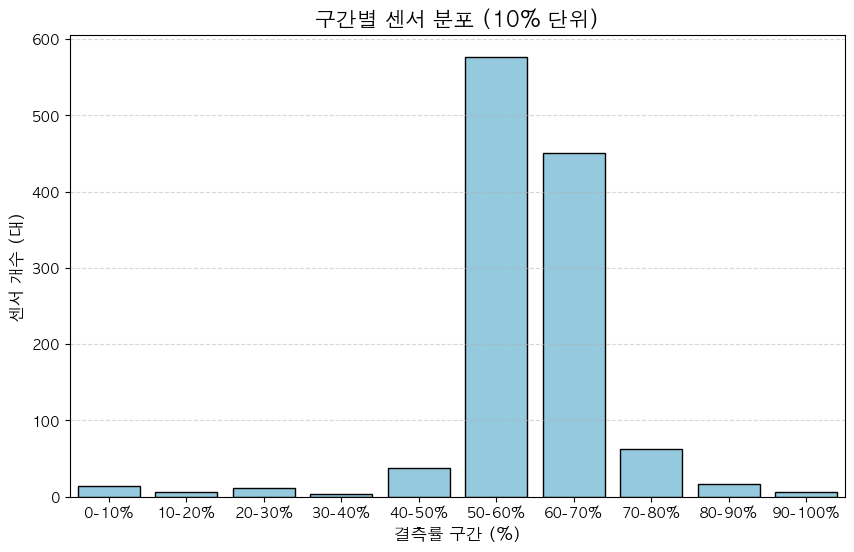

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 0~100%를 10% 간격으로 10개의 구간으로 나누기
bins = list(range(0, 101, 10))
labels = [f"{i}-{i+10}%" for i in range(0, 100, 10)]

# 2. pd.cut을 이용해 센서별 구간(bin) 할당
df_eda['missing_group'] = pd.cut(df_eda['overall_missing_rate'], bins=bins, labels=labels, include_lowest=True)

# 3. 구간별 센서 개수 집계
summary_table = df_eda['missing_group'].value_counts().sort_index().reset_index()
summary_table.columns = ['결측률 구간', '센서 개수(대)']

# 결과 출력
print("📌 [ 센서 결측률 10% 구간별 분포 ]")
display(summary_table)

# 4. 시각화 (막대 그래프)
plt.figure(figsize=(10, 6))
sns.barplot(data=summary_table, x='결측률 구간', y='센서 개수(대)', color='skyblue', edgecolor='black')
plt.title('구간별 센서 분포 (10% 단위)', fontsize=15, fontweight='bold')
plt.xlabel('결측률 구간 (%)', fontsize=12)
plt.ylabel('센서 개수 (대)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()